In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import processing

In [49]:
data = processing.get_data()
processing.getTable(2023)


,Team,Played,Won,Drawn,Lost,GF,GA,GD,Points
1,Arsenal,26,20,3,3,59,25,34,63
2,Manchester City,26,18,4,4,66,25,41,58
3,Manchester Utd,26,16,4,6,42,35,7,52
4,Newcastle Utd,26,12,11,3,44,19,25,47
5,Tottenham,26,14,3,9,46,36,10,45
6,Brighton,26,13,5,8,47,33,14,44
7,Liverpool,26,12,7,7,47,28,19,43
8,Brentford,26,10,11,5,42,33,9,41
9,Fulham,26,11,6,9,38,34,4,39
10,Aston Villa,26,11,4,11,33,39,-6,37


In [30]:
data.isna().sum()

Season_End_Year    0
Wk                 0
Date               0
Home               0
HomeGoals          0
AwayGoals          0
Away               0
FTR                0
WinningTeams       0
dtype: int64

In [31]:
for col in data.columns:
    if data[col].dtype == 'object': #columns are called in this format df['column name'] so thats why we put 'data[col]'
        print(col)

Date
Home
Away
FTR
WinningTeams


In [32]:
data['FTR'].value_counts()

FTR
H    5519
A    3410
D    3097
Name: count, dtype: int64

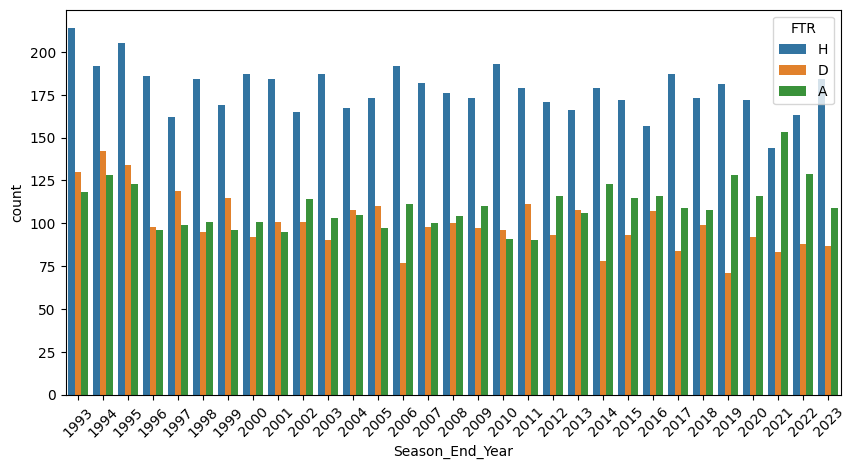

In [33]:
plt.figure(figsize=(10,5))
sns.countplot(x= data['Season_End_Year'],hue=data['FTR'])
plt.xticks(rotation=45)
plt.show()

In [34]:
pd.set_option('display.max_rows',1000)

In [35]:
a = data.groupby('Home')['FTR'].value_counts()
a.head(500)


Home             FTR
Arsenal          H      382
                 D      134
                 A       79
Aston Villa      H      220
                 A      165
                 D      153
Barnsley         A        8
                 H        7
                 D        4
Birmingham City  H       50
                 D       46
                 A       37
Blackburn        H      169
                 A       94
                 D       85
Blackpool        A        9
                 D        5
                 H        5
Bolton           H       93
                 A       79
                 D       75
Bournemouth      A       45
                 H       40
                 D       29
Bradford City    D       15
                 A       13
                 H       10
Brentford        H       17
                 A       11
                 D       10
Brighton         D       40
                 A       37
                 H       37
Burnley          A       62
                 H       52

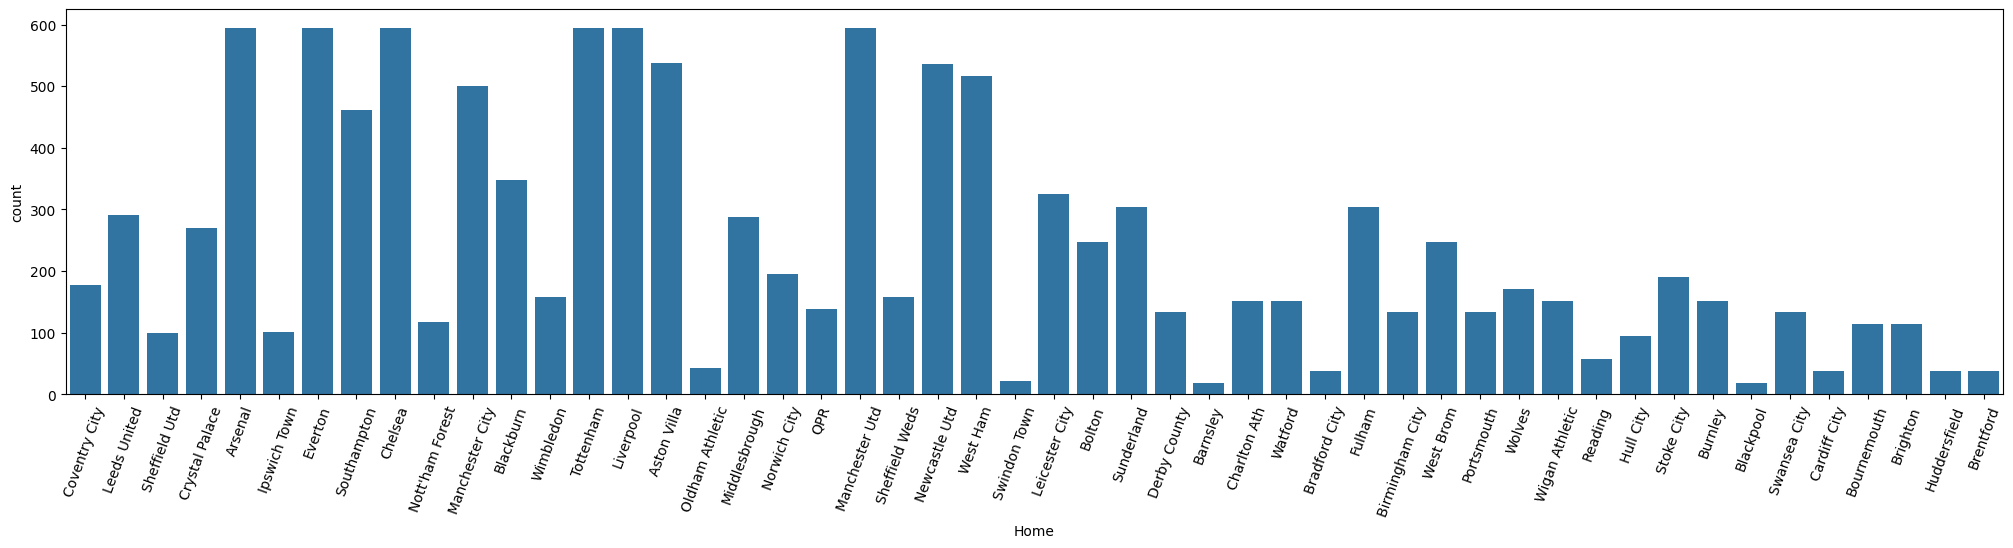

In [36]:
plt.figure(figsize=(25,5))
sns.countplot(x=data['Home'],data=data)
plt.xticks(rotation=70)
plt.show()

In [37]:
winning_teams = []

for index,rows in data.iterrows():
    hg = rows['HomeGoals']
    ag = rows['AwayGoals']
    ht = rows['Home']
    at = rows['Away']

    if hg > ag:
        winning_teams.append(ht)
    elif hg == ag:
        winning_teams.append('Draw')
    else:
        winning_teams.append(at)



In [38]:
data['WinningTeams'] = winning_teams
data

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR,WinningTeams
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H,Coventry City
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H,Leeds United
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H,Sheffield Utd
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D,Draw
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A,Norwich City
...,...,...,...,...,...,...,...,...,...
12021,2023,38,2023-05-28,Everton,1,0,Bournemouth,H,Everton
12022,2023,38,2023-05-28,Leicester City,2,1,West Ham,H,Leicester City
12023,2023,38,2023-05-28,Aston Villa,2,1,Brighton,H,Aston Villa
12024,2023,38,2023-05-28,Leeds United,1,4,Tottenham,A,Tottenham


In [39]:
data.WinningTeams.value_counts()

WinningTeams
Draw               3097
Manchester Utd      726
Arsenal             645
Chelsea             629
Liverpool           628
Tottenham           520
Manchester City     501
Everton             426
Newcastle Utd       401
Aston Villa         372
West Ham            346
Southampton         280
Blackburn           262
Leeds United        223
Leicester City      218
Fulham              177
Middlesbrough       165
Crystal Palace      156
Sunderland          153
Bolton              149
West Brom           117
Stoke City          116
Wolves              101
Sheffield Weds      101
Coventry City        99
Wimbledon            99
Norwich City         99
Charlton Ath         93
Wigan Athletic       85
Burnley              83
Swansea City         82
QPR                  81
Portsmouth           79
Watford              73
Birmingham City      73
Nott'ham Forest      69
Derby County         68
Bournemouth          67
Brighton             66
Ipswich Town         57
Sheffield Utd        53
Hul

In [40]:

pd.set_option('display.max_rows',1000)

A = data.groupby('WinningTeams')['FTR'].value_counts()
A

WinningTeams     FTR
Arsenal          H       382
                 A       263
Aston Villa      H       220
                 A       152
Barnsley         H         7
                 A         3
Birmingham City  H        50
                 A        23
Blackburn        H       169
                 A        93
Blackpool        A         5
                 H         5
Bolton           H        93
                 A        56
Bournemouth      H        40
                 A        27
Bradford City    H        10
                 A         4
Brentford        H        17
                 A        11
Brighton         H        37
                 A        29
Burnley          H        52
                 A        31
Cardiff City     H        11
                 A         6
Charlton Ath     H        58
                 A        35
Chelsea          H       360
                 A       269
Coventry City    H        65
                 A        34
Crystal Palace   H        84
                 A    

In [41]:
data.head(5)

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR,WinningTeams
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H,Coventry City
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H,Leeds United
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H,Sheffield Utd
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D,Draw
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A,Norwich City
